# [Set 1] Question 10

## Problem Statement
Write a program to arrange a series of numbers (containing known number of terms) in ascending order. Use BUBBLE SORT algorithm to implement this. 

## Analysis of Problem Statement

- A series of numbers is given as an input. It may contain any element in the set of real numbers without any need to handle NaNs. In MATLAB, we can use the `double` datatype for this.
- We can accept two things from the user:
    - The array of numbers to be sorted.
    - The condition for sorting of the numbers (here, ascending order, so swap when the left number is greater than the right number).
- We have to return the sorted array of numbers as output.

## About the Algorithm

- Broadly, the bubble sort algorithm works by iterating over the array with two nested loops and comparing adjacent elements.
- Every set of inner iterations goes through the array and swaps adjacent elements if they are in the wrong order, so the largest unsorted element "bubbles" to the end.
- Every outer iteration thus 'bubbles' the next largest element to its correct position in the array.
- This process can be slightly improved by tracking if any swaps were made in a particular pass. If no swaps were made, the array is already sorted, and we can terminate early.


## Algorithms

### Bruteforce Approach

- **Step 01.** START

- **Step 02.** Read the series of numbers, `array` and its length, `arrayLength`
- **Step 03.** Initialize a counter for total number of passes, `outerTotalPasses` = 1
- **Step 04.** Initialize a counter for total number of swaps, `position` = 1
- **Step 05.** Condition: `array[position]` > `array[position + 1]`
    - **Step 05.a. [true]** Swap the two elements
    - **Step 05.b. [false]** Continue

- **Step 06.** Increment `position` by 1
- **Step 07.** Condition: `position` < `arrayLength - outerTotalPasses`
    - **Step 07.a. [true]** go to **Step 05**
    - **Step 07.b. [false]** continue

- **Step 08.** Increment `outerTotalPasses` by 1
- **Step 09.** Condition: `outerTotalPasses` < `arrayLength`
    - **Step 09.a. [true]** go to **Step 04**
    - **Step 09.b. [false]** continue

- **Step 10.** Return the sorted array, `array`

- **Step 11.** STOP

<!-- pagebreak -->

### Optimized Approach [with early stopping]

- **Step 01.** START

- **Step 02.** Read the series of numbers, `array` and its length, `arrayLength`
- **Step 03.** Initialize a counter for total number of passes, `outerTotalPasses` = 1
- **Step 04.** Initialize a counter for total number of swaps, `position` = 1
- **Step 05.** Initialize a flag to track if any swaps were made, `wasSwapped` = false
- **Step 06.** Condition: `array[position]` > `array[position + 1]`
    - **Step 06.a. [true]** Swap the two elements; Set `wasSwapped` = true
    - **Step 06.b. [false]** Continue

- **Step 07.** Increment `position` by 1
- **Step 08.** Condition: `position` < `arrayLength - outerTotalPasses`
    - **Step 08.a. [true]** go to **Step 06**
    - **Step 08.b. [false]** continue

- **Step 09.** Condition: `wasSwapped` == false
    - **Step 09.a. [true]** go to **Step 12**
    - **Step 09.b. [false]** continue

- **Step 10.** Increment `outerTotalPasses` by 1
- **Step 11.** Condition: `outerTotalPasses` < `arrayLength`
    - **Step 11.a. [true]** go to **Step 04**
    - **Step 11.b. [false]** continue

- **Step 12.** Return the sorted array, `array`

- **Step 13.** STOP

## Complexity Analysis

- The space complexity of the bubble-sort algorithm remains $O(n)$, since we simply iterate over the same array and sort in place.
- The time complexity of this algorithm is $O(n^2)$ in the worst case, since it iterates over the array twice sorting the last element with n iterations at worst, and so on for n elements.

<!-- pagebreak -->

## Implementations

### Bruteforce Approach

In [8]:
%%file bubbleSortBruteforce.m
function array = bubbleSortBruteforce(array, compareFunction) %#ok<FNDEF>
    % @parameter array: array to be sorted
    % @parameter compareFunction: function comparing to determine sorting order

    % @return array: the array, sorted in-place

    arrayLength = length(array);
    outerTotalPasses = 1;

    while outerTotalPasses < arrayLength
        position = 1;

        while position <= arrayLength - outerTotalPasses

            if compareFunction(array(position), array(position + 1))
                [array(position), array(position + 1)] = ...
                    deal(array(position + 1), array(position));
            end

            position = position + 1;
        end % inner while loop ends, one position is checked

        outerTotalPasses = outerTotalPasses + 1;
    end % outer while loop ends, one pass through the array is completed
end


File bubbleSortBruteforce.m created successfully.

In [10]:
% --- INPUT ---
ascendingOrderSwapCondition = @(a, b) logical(a > b);
randomArrayGenerator = @(n, lower, upper) rand(n, 1) * (upper - lower) + lower;

disp("--- INPUT ---");
disp("Random array of 6 elements between -100 and 100:");
randomArray = randomArrayGenerator(6, -100, 100);
disp(randomArray');

% --- OUTPUT ---
orderedArray = bubbleSortBruteforce(randomArray, ascendingOrderSwapCondition);

disp("--- OUTPUT ---");
disp("Sorted array in ascending order [Bubble sort with bruteforce]:");
disp(orderedArray');

--- INPUT ---
Random array of 6 elements between -100 and 100:
  -56.0802  -32.8984  -19.3836   21.5917  -70.6580  -21.6147

--- OUTPUT ---
Sorted array in ascending order [Bubble sort with bruteforce]:
  -70.6580  -56.0802  -32.8984  -21.6147  -19.3836   21.5917



<!-- pagebreak -->

### Approach with Early Stopping

In [11]:
%%file bubbleSortEarlyStopping.m
function array = bubbleSortEarlyStopping(array, compareFunction) %#ok<FNDEF>
    % @parameter array: array to be sorted
    % @parameter compareFunction: function comparing to determine sorting order

    % @return array: the array, sorted in-place

    arrayLength = length(array);
    outerTotalPasses = 1;

    while outerTotalPasses < arrayLength
        position = 1;
        wasSwapped = false;

        while position <= arrayLength - outerTotalPasses

            if compareFunction(array(position), array(position + 1))
                [array(position), array(position + 1)] = ...
                    deal(array(position + 1), array(position));
                wasSwapped = true;
            end

            position = position + 1;
        end % inner while loop ends, one position is checked

        if ~wasSwapped; break; end

        outerTotalPasses = outerTotalPasses + 1;
    end % outer while loop ends, one pass through the array is completed
end


File bubbleSortEarlyStopping.m created successfully.

In [12]:
% --- INPUT ---
disp("--- INPUT ---");
disp("Random array of 6 elements between -100 and 100:");
randomArray = randomArrayGenerator(6, -100, 100);
disp(randomArray');

% --- OUTPUT ---
orderedArray = bubbleSortBruteforce(randomArray, ascendingOrderSwapCondition);

disp("--- OUTPUT ---");
disp("Sorted array in ascending order [Bubble sort with early stopping]:");
disp(orderedArray');

--- INPUT ---
Random array of 6 elements between -100 and 100:
  -57.0788    1.2463  -13.7321   61.4881   -4.9433   83.8076

--- OUTPUT ---
Sorted array in ascending order [Bubble sort with early stopping]:
  -57.0788  -13.7321   -4.9433    1.2463   61.4881   83.8076



## Further Discussion

- We have assumed that no NaN or garbage values are present in the input array and the comparing function is consistent. We can further improve this by adding checks on these input arguments
- While it is easy to implement, bubble sort still has a higher time complexity than other sorting algorithms.

<!-- pagebreak -->

# [Set 2] Question 5

## Problem Statement
Solve the following equations by Newton – Raphson method: $x^4-x-10=0$

## Analysis of Problem Statement

- We make an assumption that this function, as well as its derivative is defined already, and used as input to the algorithm, along with the initial guess. The root of the function is also well defined.
- We can have multiple kinds of stopping criteria, like:
    - A maximum number of iterations
    - A tolerance factor between two consecutive guesses
- We return a single value as a guess for the root of the function, or some more data to plot a graph.

## About the Algorithm

- Newton-Raphson method iteratively determines the root of a function by moving a guess closer to the root with the help of its derivative.
- At every guess $x_n$, we find the slope of the tangent line, and a point that lies on the x-axis, $x_{n+1}$: $$f'(x_n) = \frac{f(x_n) - 0}{x_n - x_{n+1}} \implies x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$
- With an initial guess $x_0$, the next guess is calculated as: $$ x_{1} = x_0 - \frac{f(x_0)}{f'(x_0)} $$
- Until we reach a stopping criteria, we keep updating the guess with the above formula.
    - If the criteria is a maximum number of iterations, we stop after that many iterations.
    - If the criteria is a tolerance factor, we stop when the difference between two consecutive guesses is less than the tolerance factor: $$ |x_{n+1} - x_n| < \epsilon $$
- However, if the initial guess is too far from the root, such that it encounters a **critical point**. The slope of the tangent from a guess farther away from the root draws the next guess farther away, as the derivative can point in a different direction.


## Algorithm

- **Step 01.** START

- **Step 02.** Read the function, `f`, its derivative, `f'`, the initial guess, `x0`, and the stopping criteria, `maxIterations` and `tolerance`
- **Step 03.** Initialize a counter for the current iteration, `iteration` = 0
- **Step 04.** Condition: `iteration` < `maxIterations` and `|f(x0)|` > `tolerance`
    - **Step 04.a. [true]**:
        - **Step 04.a.a.** Update the guess as per formula
        - **Step 04.a.b.** Set `x0` = `x1`;
        - **Step 04.a.c.** Increment `iteration` by 1;
        - **Step 04.a.d.** Go to **Step 04**

    - **Step 04.b. [false]** Continue

- **Step 05.** Return the root, `x0`
- **Step 06.** STOP

<!-- pagebreak -->

## Implementation

In [5]:
%%file newtonRaphsonSolver.m
function [root, final_iter, guess_history] = newtonRaphsonSolver(f, df, initial_guess, tolerance, maxIterations) %#ok<FNDEF>
    % @parameter f: numeric equation with rhs = 0
    % @parameter df: derivative of the numeric equation
    % @parameter initial_guess: initial guess for root
    % @parameter tolerance: stopping factor, compared to difference between consecutive guesses
    % @parameter maxIterations: stopping factor, compared to limit iteration count

    % @return root: the final guess for the root
    % @return final_iter: the number of iterations taken to converge to that root
    % @return guess_history: the array of guesses made during each iteration

    % default arguments
    if nargin < 5; maxIterations = 100; end
    if nargin < 4; tolerance = 1e-6; end

    guess_history = zeros(maxIterations, 1);
    guess_history(1) = initial_guess;

    for iter = 1:maxIterations
        current_guess = guess_history(iter);
        next_guess = current_guess - f(current_guess) / df(current_guess);
        guess_history(iter + 1) = next_guess;

        % consider both criteria, either fulfills, we break out of the loop
        stopping_criteria = ...
            iter >= maxIterations || abs(next_guess - current_guess) < tolerance;
        if stopping_criteria; break; end
    end

    root = guess_history(iter + 1);
    final_iter = iter;
    guess_history = guess_history(1:iter + 1);
end

File newtonRaphsonSolver.m created successfully.

In [6]:
% --- INPUT ---
f = @(x) x.^4 - x - 10;
df = @(x) 4*x.^3 - 1;
initial_guess = 2.0;

disp("--- INPUT ---");
disp("We take an initial guess of: " + initial_guess)

% --- OUTPUT ---
[root, final_iter, guess_history] = newtonRaphsonSolver(f, df, initial_guess);

disp(newline + "--- OUTPUT ---");
disp("The root of the equation is: " + root);
disp("The number of iterations taken to converge to that root is: " + final_iter);

--- INPUT ---
We take an initial guess of: 2

--- OUTPUT ---
The root of the equation is: 1.8556
The number of iterations taken to converge to that root is: 4


<!-- pagebreak -->

## Graph

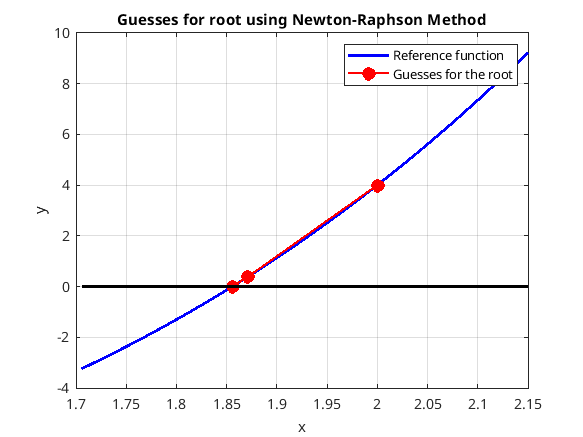

In [7]:
% put some padding around the graph
GRAPH_PADDING = 0.15;
graph_x_min = min(guess_history) - GRAPH_PADDING;
graph_x_max = max(guess_history) + GRAPH_PADDING;

% the reference function
ref_points = linspace(graph_x_min, graph_x_max, 100);
plot(ref_points, f(ref_points), "-b", "LineWidth", 2);
hold on; % why do we even need this.. bad language design

% the guesses
plot(guess_history, f(guess_history), "o-r", "LineWidth", 1.5, "MarkerSize", 8, "MarkerFaceColor", "r");

% the x-axis
plot([graph_x_min, graph_x_max], [0, 0], "-k", "LineWidth", 2);

% more details
title("Guesses for root using Newton-Raphson Method");
xlabel("x"); ylabel("y");
legend("Reference function", "Guesses for the root");
hold off; grid on;


## Further Discussion

- For $f(x)=x^4-x-10$, we see that the Newton–Raphson method converges rapidly when the initial guess (i.e. $x_0=2$) is close to the real positive root.
- Since the curve does not have any inflection points near and between the root and the initial guess, we do not observe any oscillations or divergence in the guesses.
- Our criteria of tolerance seems to have been met in 4 iterations, much less than the maximum of 100 iterations.
- This might be improved by keeping a check on the derivative. If $\frac{f(x_n)}{f'(x_n)}$ is very large, which means $f'(x_n)$ is very small, and it keeps increasing, it might be a good sign of non-convergence.